<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
 MLR & Shadow Fading Analysis 
</p>

In [18]:
# Imports - core utils, data wrangling, ML, stats, and plotting

# Standard library
import os
import pickle
import re
import time
from math import sqrt

# Prevent BLAS oversubscription; we parallelize at sklearn/joblib level
os.environ["MKL_NUM_THREADS"]     = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"]     = "1"
os.environ["NUMEXPR_MAX_THREADS"] = "1"

# Data handling
import numpy as np
import pandas as pd
from IPython.display import display

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator

# ML (scikit-learn)
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.mixture import GaussianMixture
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Stats
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from scipy.interpolate import interp1d
from scipy.stats import kstest, norm, t, skewnorm, cauchy

# Parallel
from joblib import Parallel, delayed, dump

# Parallelism knob
N_JOBS = -1  # Use all available cores

#### Data paths, loading, and preparation

In [19]:
# Paths

TRAIN_CSV  = 'Data_Files/train.csv'
TEST_CSV   = 'Data_Files/test.csv'
FOLDS_NPY  = 'Data_Files/train_folds.npy'

# Load splits
df_train = pd.read_csv(TRAIN_CSV)
df_test  = pd.read_csv(TEST_CSV)
fold_assignments = np.load(FOLDS_NPY)

# Feature/target setup (physics-consistent)
raw_feats  = ['distance','frequency','c_walls','w_walls', 'co2','humidity','pm25','pressure','temperature','snr']
target_col = 'PL'

# Train/test matrices
Xtr_raw = df_train[raw_feats].copy()
ytr_pl  = df_train[target_col].astype(float).values
Xte_raw = df_test[raw_feats].copy()
yte_pl  = df_test[target_col].astype(float).values

def slug(obj):
    """Filename-safe tag for model/config (kept readable)."""
    if isinstance(obj, dict) and obj:
        items = []
        for k in sorted(obj.keys()):
            v = obj[k]
            if isinstance(v, (float, np.floating)): v = float(v)
            items.append(f"{k}={v}")
        s = "__".join(items)
    else:
        s = str(obj) if obj not in (None, {}, []) else ""
    return re.sub(r"[^A-Za-z0-9._=-]+", "_", s).strip("_")

# Required columns check 
required_cols = ['PL', 'device_id', 'distance','frequency','c_walls','w_walls', 'co2','humidity','pm25','pressure','temperature','snr']
missing = [c for c in required_cols if c not in df_train.columns or c not in df_test.columns]
if missing:
    raise ValueError(f"Missing required columns in train/test: {missing}")

#### Physics-consistent linearization + helpers + model specs

In [20]:
# Linearize (Friis-adjusted): y_adj = PL - 20*log10(f)
d0 = 1.0
def z_of_d(d): 
    return 10.0*np.log10(np.clip(d.astype(float), 1e-6, None)/d0)
def f_term(f):
    return 20.0*np.log10(np.clip(f.astype(float), 1e-12, None))

# Adjusted targets
ftr_tr, ftr_te = f_term(Xtr_raw['frequency'].values), f_term(Xte_raw['frequency'].values)
ytr_adj, yte_adj = ytr_pl - ftr_tr, yte_pl - ftr_te

# Linear feature maps
cols = ['z_d','c_walls','w_walls','co2','humidity','pm25','pressure','temperature','snr']
Xtr_lin = pd.DataFrame({
    'z_d': z_of_d(Xtr_raw['distance'].values),
    'c_walls': Xtr_raw['c_walls'].values,
    'w_walls': Xtr_raw['w_walls'].values,
    'co2': Xtr_raw['co2'].values,
    'humidity': Xtr_raw['humidity'].values,
    'pm25': Xtr_raw['pm25'].values,
    'pressure': Xtr_raw['pressure'].values,
    'temperature': Xtr_raw['temperature'].values,
    'snr': Xtr_raw['snr'].values
}, columns=cols).values

Xte_lin = pd.DataFrame({
    'z_d': z_of_d(Xte_raw['distance'].values),
    'c_walls': Xte_raw['c_walls'].values,
    'w_walls': Xte_raw['w_walls'].values,
    'co2': Xte_raw['co2'].values,
    'humidity': Xte_raw['humidity'].values,
    'pm25': Xte_raw['pm25'].values,
    'pressure': Xte_raw['pressure'].values,
    'temperature': Xte_raw['temperature'].values,
    'snr': Xte_raw['snr'].values
}, columns=cols).values

# Param labels (for reporting)
param_names = [
    'PL(d0) [dB]', 'Path loss exponent (n)',
    'Brick Wall Loss (L_c) [dB]', 'Wood Wall Loss (L_w) [dB]',
    'CO2 coef. [dB/unit]', 'Humidity coef. [dB/%]',
    'PM2.5 coef. [dB/µg/m³]', 'Pressure coef. [dB/hPa]',
    'Temp. coef. [dB/°C]', 'SNR scaling (k_snr)'
]

# Helpers
def unscale_coefficients(pipeline):
    """Undo StandardScaler effect → coeffs in original units."""
    steps = pipeline.named_steps
    est = steps.get('ridge') or steps.get('lasso') or steps.get('elasticnet') or steps.get('linearregression')
    if 'standardscaler' not in steps:
        return float(est.intercept_), est.coef_.astype(float).copy()
    scaler = steps['standardscaler']
    beta_scaled = est.coef_.astype(float)
    mu, sig = scaler.mean_, scaler.scale_
    beta_orig = beta_scaled / sig
    intercept_orig = float(est.intercept_ - np.sum(beta_scaled * mu / sig))
    return intercept_orig, beta_orig

def fold_indices(folds, k):
    val_idx = np.where(folds == k)[0]
    tr_idx  = np.where(folds != k)[0]
    return tr_idx, val_idx

def rmse_r2_on_PL(y_true_pl, y_pred_adj, fterm):
    """Score in PL-domain (add back freq term)."""
    y_pred_pl = y_pred_adj + fterm
    rmse = sqrt(mean_squared_error(y_true_pl, y_pred_pl))
    r2   = r2_score(y_true_pl, y_pred_pl)
    return rmse, r2

# Model factories
def make_OLS(_): return make_pipeline(LinearRegression())
def make_Ridge(cfg): return make_pipeline(StandardScaler(), Ridge(alpha=cfg["alpha"], random_state=42))
def make_Lasso(cfg): return make_pipeline(StandardScaler(), Lasso(alpha=cfg["alpha"], max_iter=20000, random_state=42))
def make_ElasticNet(cfg): return make_pipeline(
    StandardScaler(),
    ElasticNet(alpha=cfg["alpha"], l1_ratio=cfg["l1_ratio"], max_iter=20000, random_state=42)
)

# Grids
ridge_grid = [dict(alpha=a) for a in np.logspace(-4, 3, 15)]
lasso_grid = [dict(alpha=a) for a in np.logspace(-4, 1, 15)]
enet_grid  = [dict(alpha=a, l1_ratio=r) for a in np.logspace(-4, 1, 10) for r in (0.2, 0.5, 0.8)]

# Spec list
specs = [
    ("OLS",        make_OLS,        [dict()]),
    ("Ridge",      make_Ridge,      ridge_grid),
    ("Lasso",      make_Lasso,      lasso_grid),
    ("ElasticNet", make_ElasticNet, enet_grid),
]

#### Time-aware K-fold CV on the train split to pick the best config per MLR variant, then refit on full train subset

In [21]:
# K-fold CV over each MLR model
results = []
K = int(np.max(fold_assignments)) + 1

# Precompute indices once (saves a bit)
folds = [fold_indices(fold_assignments, k) for k in range(K)]

print(f"Running CV for  {len(specs)} MLR variants | K={len(folds)} folds | grid eval={'parallel...' if (N_JOBS != 1) else 'sequential...'}")

residuals_list = []  # collect per-model test residual DataFrames for saving

t0 = time.time()

def eval_cfg(factory, cfg, folds):
    tr_rmse_list, val_rmse_list, tr_r2_list, val_r2_list = [], [], [], []
    for tr_idx, val_idx in folds:
        X_tr, X_val = Xtr_lin[tr_idx], Xtr_lin[val_idx]
        y_tr, y_val = ytr_adj[tr_idx], ytr_adj[val_idx]
        ypl_tr, ypl_val = ytr_pl[tr_idx], ytr_pl[val_idx]
        f_tr,  f_val  = ftr_tr[tr_idx],  ftr_tr[val_idx]

        pipe = factory(cfg)
        pipe.fit(X_tr, y_tr)

        y_tr_pred_adj = pipe.predict(X_tr)
        rmse_tr, r2_tr = rmse_r2_on_PL(ypl_tr, y_tr_pred_adj, f_tr)
        tr_rmse_list.append(rmse_tr); tr_r2_list.append(r2_tr)

        y_val_pred_adj = pipe.predict(X_val)
        rmse_val, r2_val = rmse_r2_on_PL(ypl_val, y_val_pred_adj, f_val)
        val_rmse_list.append(rmse_val); val_r2_list.append(r2_val)

    return {
        "cfg": cfg,
        "rmse_train_mean": float(np.mean(tr_rmse_list)), "rmse_train_sd": float(np.std(tr_rmse_list)),
        "rmse_val_mean":   float(np.mean(val_rmse_list)), "rmse_val_sd":   float(np.std(val_rmse_list)),
        "r2_train_mean":   float(np.mean(tr_r2_list)),    "r2_train_sd":    float(np.std(tr_r2_list)),
        "r2_val_mean":     float(np.mean(val_r2_list)),   "r2_val_sd":      float(np.std(val_r2_list)),
    }

for name, factory, grid in specs:
    if len(grid) == 1:  # OLS: no sweep
        grid_results = [eval_cfg(factory, grid[0], folds)]
    else:
        # Parallelize across configs; BLAS is single-threaded (from header), so this scales well.
        grid_results = Parallel(n_jobs=N_JOBS, backend="threading", prefer="threads", verbose=0)(
            delayed(eval_cfg)(factory, cfg, folds) for cfg in grid
        )

    best_res = min(grid_results, key=lambda r: r["rmse_val_mean"])
    best_cfg, best_cv = best_res["cfg"], {k: v for k, v in best_res.items() if k != "cfg"}

    # Refit on all training data with best hyperparams
    final_pipe = factory(best_cfg)
    final_pipe.fit(Xtr_lin, ytr_adj)

    # Test metrics (PL domain)
    yte_pred_adj = final_pipe.predict(Xte_lin)
    test_rmse, test_r2 = rmse_r2_on_PL(yte_pl, yte_pred_adj, ftr_te)

    # Build residuals on the 20% test split (uniform schema)
    PL_pred  = yte_pred_adj + ftr_te
    resid_db = yte_pl - PL_pred
    tag_cfg  = slug(best_cfg)
    model_tag = f"MLR_{name}" if tag_cfg == "" else f"MLR_{name}__{tag_cfg}"

    # Coefficients back in original units
    intercept_orig, beta_orig = unscale_coefficients(final_pipe)
    coeffs = np.concatenate(([intercept_orig], beta_orig))
    coeffs_series = pd.Series(coeffs, index=param_names, name=name)

    results.append({
        "model":       name,
        "best_cfg":    best_cfg,
        "cv":          best_cv,
        "test":        {"rmse": float(test_rmse), "r2": float(test_r2)},
        "coeffs":      coeffs_series,
        "final_pipe":  final_pipe,   # keep the fitted pipeline
        "model_tag":   model_tag     # tag used for filenames
    })

t1 = time.time()
print(f"\nDone processing in {(t1 - t0)/60:.2f} minutes.!")

Running CV for  4 MLR variants | K=5 folds | grid eval=parallel...

Done processing in 1.68 minutes.!


#### MLR CV summary (mean ± sd across folds), best model highlighted, then OOF residuals for BEST are saved.

In [22]:
# Best MLR by mean CV Val RMSE 
best_overall  = min(results, key=lambda r: r["cv"]["rmse_val_mean"])
best_name     = best_overall["model"]      # OLS / Ridge / Lasso / ElasticNet
best_cfg      = best_overall["best_cfg"]
best_long_tag = best_overall["model_tag"]

def mlr_short_tag(name: str) -> str:
    return f"MLR_{name}"

best_tag_short = mlr_short_tag(best_name)

# CV-only summary table (TRAIN split only)
rows = []
for r in results:
    cfg = r.get("best_cfg", {}) if isinstance(r.get("best_cfg", {}), dict) else {"cfg": str(r.get("best_cfg"))}
    rows.append({
        "model":            mlr_short_tag(r["model"]),
        "is_best":          (r["model_tag"] == best_long_tag),
        "cv_rmse_val_mean": r["cv"]["rmse_val_mean"],
        "cv_rmse_val_sd":   r["cv"]["rmse_val_sd"],
        "cv_r2_val_mean":   r["cv"]["r2_val_mean"],
        "alpha":            cfg.get("alpha", np.nan),
        "l1_ratio":         cfg.get("l1_ratio", np.nan),
    })

mlr_cv_table = (pd.DataFrame(rows)
                .sort_values(["cv_rmse_val_mean", "cv_rmse_val_sd", "model"])
                .reset_index(drop=True))

display(mlr_cv_table)

# BEST residuals on TEST (refit on full TRAIN already stored in best_overall["final_pipe"])
best_pipe = best_overall["final_pipe"]
yte_pred_adj = best_pipe.predict(Xte_lin)

PL_pred_test = yte_pred_adj + ftr_te
resid_test   = yte_pl - PL_pred_test

mlr_test_df = pd.DataFrame({
    "model":       "MLR_BEST",
    "split":       "test",
    "row_id":      np.arange(len(df_test), dtype=int),
    "time":        df_test.get("time", pd.Series(index=df_test.index, dtype=float)).values,
    "device_id":   df_test["device_id"].values,
    "distance":    df_test["distance"].values,
    "frequency":   df_test["frequency"].values,
    "c_walls":     df_test["c_walls"].values,
    "w_walls":     df_test["w_walls"].values,
    "co2":         df_test["co2"].values,
    "humidity":    df_test["humidity"].values,
    "pm25":        df_test["pm25"].values,
    "pressure":    df_test["pressure"].values,
    "temperature": df_test["temperature"].values,
    "snr":         df_test["snr"].values,
    "PL_true":     yte_pl,
    "PL_pred":     PL_pred_test,
    "resid_db":    resid_test
})

test_path = "Residuals/residuals_MLR_test.csv"
mlr_test_df.to_csv(test_path, index=False)
print(f"\n[TEST] Saved best MLR test residuals: {test_path}")

# OOF residuals for BEST (train-only)
factory_for_best = next(f for (n, f, g) in specs if n == best_name)

y_pred_adj_oof = np.full(len(ytr_adj), np.nan, dtype=float)
for tr_idx, val_idx in folds:
    pipe = factory_for_best(best_cfg)
    pipe.fit(Xtr_lin[tr_idx], ytr_adj[tr_idx])
    y_pred_adj_oof[val_idx] = pipe.predict(Xtr_lin[val_idx])

mask = ~np.isnan(y_pred_adj_oof)

PL_pred_oof = y_pred_adj_oof[mask] + ftr_tr[mask]
resid_oof   = ytr_pl[mask] - PL_pred_oof

mlr_oof_df = pd.DataFrame({
    "model":       "MLR_BEST",
    "split":       "oof",
    "row_id":      np.arange(len(df_train), dtype=int)[mask],
    "fold":        fold_assignments.astype(int)[mask],
    "time":        df_train.get("time", pd.Series(index=df_train.index, dtype=float)).values[mask],
    "device_id":   df_train["device_id"].values[mask],
    "distance":    df_train["distance"].values[mask],
    "frequency":   df_train["frequency"].values[mask],
    "c_walls":     df_train["c_walls"].values[mask],
    "w_walls":     df_train["w_walls"].values[mask],
    "co2":         df_train["co2"].values[mask],
    "humidity":    df_train["humidity"].values[mask],
    "pm25":        df_train["pm25"].values[mask],
    "pressure":    df_train["pressure"].values[mask],
    "temperature": df_train["temperature"].values[mask],
    "snr":         df_train["snr"].values[mask],
    "PL_true":     ytr_pl[mask],
    "PL_pred":     PL_pred_oof,
    "resid_db":    resid_oof
})

oof_path = "Residuals/residuals_MLR_oof.csv"
mlr_oof_df.to_csv(oof_path, index=False)
print(f"\n[OOF] Saved best MLR OOF residuals: {oof_path}")

# Save final BEST MLR model fitted on all training data

os.makedirs("Models", exist_ok=True)

best_model_path = "Models/mlr_final_model.pkl" 

with open(best_model_path, "wb") as f:
    pickle.dump(best_pipe, f)

print(f"\nFinal BEST MLR model saved to {best_model_path}")
print(f"\nSelected model: {best_tag_short}")
print(f"\nBest config: {best_cfg}")

,model,is_best,cv_rmse_val_mean,cv_rmse_val_sd,cv_r2_val_mean,alpha,l1_ratio
0,MLR_ElasticNet,True,8.233291,0.557738,0.806084,0.059948,0.5
1,MLR_Ridge,False,8.240977,0.581891,0.805566,1000.000000,NaN
2,MLR_OLS,False,8.241577,0.582735,0.805532,NaN,NaN
3,MLR_Lasso,False,8.241578,0.582740,0.805532,0.000100,NaN



[TEST] Saved best MLR test residuals: Residuals/residuals_MLR_test.csv

[OOF] Saved best MLR OOF residuals: Residuals/residuals_MLR_oof.csv

Final BEST MLR model saved to Models/mlr_final_model.pkl

Selected model: MLR_ElasticNet

Best config: {'alpha': 0.05994842503189409, 'l1_ratio': 0.5}


#### Final held-out evaluation on the 20% test split for the CV-selected model

In [23]:
# Final test evaluation (held-out 20%): selected model only
test_rows = []
for res in results:
    te = res["test"]
    test_rows.append({
        "Model": res["model"],
        "Test RMSE": float(te["rmse"]),
        "Test R2":   float(te["r2"]),
    })

# Frame + display
test_df = pd.DataFrame(test_rows)
display(test_df)

,Model,Test RMSE,Test R2
0,OLS,8.453447,0.798423
1,Ridge,8.454240,0.798385
2,Lasso,8.453403,0.798425
3,ElasticNet,8.484460,0.796941


#### Coefficient table (all models, final fits, original units)

In [24]:
# Collect coeffs side by side
coef_df = pd.concat([res['coeffs'] for res in results], axis=1)
coef_df.columns = [res['model'] for res in results]

print("\n Harmonized Coefficients (final all-train fits, original units) ")
display(coef_df)


 Harmonized Coefficients (final all-train fits, original units) 


,OLS,Ridge,Lasso,ElasticNet
PL(d0) [dB],2.305528,2.359624,2.298639,2.454082
Path loss exponent (n),3.866506,3.860131,3.866596,3.623919
Brick Wall Loss (L_c) [dB],6.830244,6.833462,6.829939,6.841285
Wood Wall Loss (L_w) [dB],1.977092,1.984641,1.976906,2.221589
CO2 coef. [dB/unit],-0.002355,-0.002361,-0.002354,-0.002453
Humidity coef. [dB/%],-0.091712,-0.091503,-0.091687,-0.074745
PM2.5 coef. [dB/µg/m³],-0.095295,-0.094584,-0.095261,-0.056054
Pressure coef. [dB/hPa],-0.008045,-0.008044,-0.008033,-0.004172
Temp. coef. [dB/°C],-0.141028,-0.141187,-0.140993,-0.137472
SNR scaling (k_snr),-2.034426,-2.033469,-2.034403,-1.980566


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
ANOVA and Shadow Fading Analysis

In [25]:
# Construct OLS training frame from variables already defined in this notebook
df_ols = df_train[raw_feats + [target_col]].copy()

# Transform distance and frequency
dist = df_ols['distance'].astype(float).clip(lower=1e-6)
freq = df_ols['frequency'].astype(float).clip(lower=1e-12)

df_ols['log_dist_factor'] = 10 * np.log10(dist / 1.0)
df_ols['log_freq_factor'] = 20 * np.log10(freq)

# Fit OLS model with transformed predictors
formula = (
    'PL ~ log_dist_factor + log_freq_factor + c_walls + w_walls + co2 + '
    'humidity + pm25 + pressure + temperature + snr'
)

model = smf.ols(formula=formula, data=df_ols).fit()

# Extract residuals from the model
residuals = model.resid
n = len(residuals)
sorted_residuals = np.sort(residuals)
probabilities = (np.arange(1, n + 1) - 0.5) / n

display(model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     PL   R-squared:                       0.820
Model:                            OLS   Adj. R-squared:                  0.820
Method:                 Least Squares   F-statistic:                 7.584e+05
Date:                Mon, 18 May 2026   Prob (F-statistic):               0.00
Time:                        13:51:09   Log-Likelihood:            -5.8160e+06
No. Observations:             1663627   AIC:                         1.163e+07
Df Residuals:                 1663616   BIC:                         1.163e+07
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         1.24e+04     79.441    156.071      0.000    1.22e+04    1.26e+04
log_dist_factor     3.8649      0.005    713.371      0.000       3.854       3.876
log_freq_factor  -209.9262      1.352   -155.303      0.000    -212.575    -207.277
c_walls             6.8205      0.011    618.582      0.000       6.799       6.842
w_walls             1.9785      0.009    230.634      0.000       1.962       1.995
co2                -0.0023   5.35e-05    -43.544      0.000      -0.002      -0.002
humidity           -0.0917      0.001    -91.026      0.000      -0.094      -0.090
pm25               -0.0952      0.003    -32.173      0.000      -0.101      -0.089
pressure           -0.0083      0.001    -11.419      0.000      -0.010      -0.007
temperature        -0.1406      0.002    -81.547      0.000      -0.144      -0.137
snr                -2.0569      0.002  -1138.898      0.000      -2.060      -2.053
==============================================================================
Omnibus:                   375890.894   Durbin-Watson:                   2.019
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          1834283.444
Skew:                           1.017   Prob(JB):                         0.00
Kurtosis:                       7.725   Cond. No.                     8.03e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.03e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [26]:
#  Fit Distributions to Residuals

# 1. Normal Distribution
normal_params = norm.fit(residuals)
loc_norm, scale_norm = normal_params
normal_dist = norm(loc=loc_norm, scale=scale_norm)

# 2. Skew-Normal Distribution
skew_params = skewnorm.fit(residuals)
shape_sn, loc_sn, scale_sn = skew_params
skew_dist = skewnorm(shape_sn, loc=loc_sn, scale=scale_sn)

# 3. Gaussian Mixture Model (Automated Model Selection 1 and 2)
residuals_array = residuals.values.reshape(-1, 1)
lowest_bic = np.inf
bic_scores = []
n_components_range = range(1, 3)  # up to 2 components
best_gmm = None

for n_components in n_components_range:
    gmm_tmp = GaussianMixture(n_components=n_components, random_state=42).fit(residuals_array)
    bic_value = gmm_tmp.bic(residuals_array)
    bic_scores.append(bic_value)
    if bic_value < lowest_bic:
        lowest_bic = bic_value
        best_gmm = gmm_tmp

gmm = best_gmm  # Use the best GMM selected based on the lowest BIC
print(f"\nSelected GMM with {gmm.n_components} components based on lowest BIC: {lowest_bic}")

# 4. Cauchy Distribution
cauchy_params = cauchy.fit(residuals)
cauchy_dist = cauchy(*cauchy_params)

# 5. t-Distribution
t_params = t.fit(residuals)
df_t, loc_t, scale_t = t_params
t_dist = t(df=df_t, loc=loc_t, scale=scale_t)

#  Compute Log-Likelihood, AIC, BIC, and KS Test 
def compute_aic_bic(log_likelihood, num_params, num_samples):
    """Compute AIC and BIC values."""
    aic = 2 * num_params - 2 * log_likelihood
    bic = num_params * np.log(num_samples) - 2 * log_likelihood
    return aic, bic

# Normal Distribution
loglik_norm = np.sum(np.log(normal_dist.pdf(residuals)))
aic_norm, bic_norm = compute_aic_bic(loglik_norm, 2, n)  # 2 params: loc, scale
ks_norm = kstest(residuals, normal_dist.cdf)

# Skew-Normal Distribution
loglik_sn = np.sum(np.log(skew_dist.pdf(residuals)))
aic_sn, bic_sn = compute_aic_bic(loglik_sn, 3, n)  # 3 params: shape, loc, scale
ks_sn = kstest(residuals, skew_dist.cdf)

# Gaussian Mixture Model
loglik_gmm = gmm.score(residuals_array) * n  # score returns average log-likelihood
aic_gmm, bic_gmm = compute_aic_bic(loglik_gmm, 2 * gmm.n_components - 1, n)  # 2 parameters per component minus one

def gmm_cdf(x, gmm):
    """Compute the CDF of a Gaussian Mixture Model at points x."""
    cdf = np.zeros_like(x, dtype=float)
    for weight, mean, cov in zip(gmm.weights_, gmm.means_.flatten(), gmm.covariances_.flatten()):
        std = np.sqrt(cov)
        cdf += weight * norm.cdf(x, loc=mean, scale=std)
    return cdf

ks_gmm = kstest(residuals, lambda x: gmm_cdf(x, gmm))

# Cauchy Distribution
loglik_cauchy = np.sum(np.log(cauchy_dist.pdf(residuals)))
aic_cauchy, bic_cauchy = compute_aic_bic(loglik_cauchy, 2, n)  # 2 params: loc, scale
ks_cauchy = kstest(residuals, cauchy_dist.cdf)

# t-Distribution
loglik_t = np.sum(np.log(t_dist.pdf(residuals)))
aic_t, bic_t = compute_aic_bic(loglik_t, 3, n)  # 3 params: df, loc, scale
ks_t = kstest(residuals, t_dist.cdf)

#  Compile Diagnostics into a DataFrame 
diagnostics = pd.DataFrame({
    'Distribution': ['Normal', 'Skew-Normal', 'Gaussian Mixture Model', 'Cauchy', 't-Distribution'],
    'Log-Likelihood': [loglik_norm, loglik_sn, loglik_gmm, loglik_cauchy, loglik_t],
    'AIC': [aic_norm, aic_sn, aic_gmm, aic_cauchy, aic_t],
    'BIC': [bic_norm, bic_sn, bic_gmm, bic_cauchy, bic_t],
    'KS Test Statistic': [ks_norm.statistic, ks_sn.statistic, ks_gmm.statistic, ks_cauchy.statistic, ks_t.statistic],
    'KS Test p-value': [ks_norm.pvalue, ks_sn.pvalue, ks_gmm.pvalue, ks_cauchy.pvalue, ks_t.pvalue]
})

diagnostics['Log-Likelihood'] = diagnostics['Log-Likelihood'].round(2)
diagnostics['AIC'] = diagnostics['AIC'].round(2)
diagnostics['BIC'] = diagnostics['BIC'].round(2)
diagnostics['KS Test Statistic'] = diagnostics['KS Test Statistic'].round(4)
diagnostics['KS Test p-value'] = diagnostics['KS Test p-value'].round(4)

print("\nDiagnostics Table:")
display(diagnostics)

best_fit = diagnostics.loc[diagnostics['KS Test Statistic'].idxmin()]
print(f"\nBest Fit (Based on KS Test Statistic): {best_fit['Distribution']}\n")


Selected GMM with 2 components based on lowest BIC: 11410721.011691188

Diagnostics Table:


,Distribution,Log-Likelihood,AIC,BIC,KS Test Statistic,KS Test p-value
0,Normal,-5815980.48,11631964.95,11631989.60,0.0564,0.0
1,Skew-Normal,-5757704.06,11515414.11,11515451.09,0.0415,0.0
2,Gaussian Mixture Model,-5705324.69,11410655.39,11410692.36,0.0134,0.0
3,Cauchy,-5913526.22,11827056.44,11827081.09,0.0792,0.0
4,t-Distribution,-5710026.76,11420059.53,11420096.50,0.0219,0.0



Best Fit (Based on KS Test Statistic): Gaussian Mixture Model



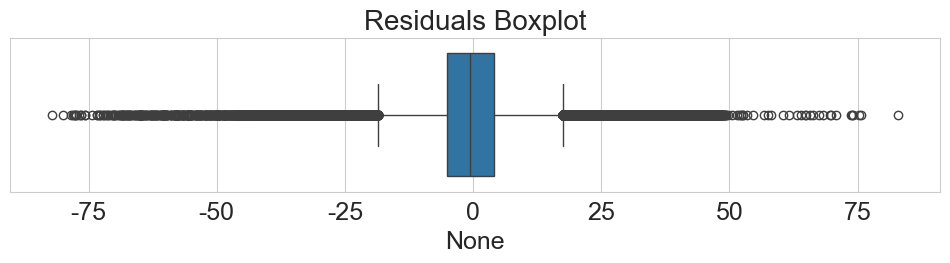

In [27]:
# Inspect Residuals for Outliers
plt.figure(figsize=(12, 2))
sns.boxplot(x=residuals)
plt.title('Residuals Boxplot')
plt.show()

In [28]:
# Convert residuals to a 2D array for GMM (required shape: [n_samples, n_features])
residuals_array = residuals.values.reshape(-1, 1)
gmm_models = []  # Define and initialize the list

# Initialize a list to store diagnostics for each GMM with different numbers of components
gmm_diagnostics = []

# Loop over the number of components (1 through 5)
for k in range(1, 6):
    # Fit GMM with k components using a fixed random state for reproducibility
    gmm_k = GaussianMixture(n_components=k, random_state=42).fit(residuals_array)
    gmm_models.append(gmm_k)
    
    # Calculate the total log-likelihood from the per-sample log probabilities.
    # Note: score_samples returns the log probability for each sample.
    loglik_k = np.sum(gmm_k.score_samples(residuals_array))
    
    # Estimate the number of free parameters for a mixture of Gaussians.
    # For each component: 1 weight (but total weights sum to 1: hence, k - 1 free parameters),
    # 1 mean, and 1 variance. Total parameters: (k - 1) + k + k = 3k - 1.
    num_params = 3 * k - 1
    
    # Compute AIC and BIC using standard formulas:    
    aic_k = 2 * num_params - 2 * loglik_k
    bic_k = num_params * np.log(len(residuals_array)) - 2 * loglik_k
    
    # Perform a Kolmogorov–Smirnov (KS) test on the residuals versus the GMM cumulative distribution.
    # We use our custom gmm_cdf function defined earlier.
    ks_result = kstest(residuals, lambda x: gmm_cdf(x, gmm_k))
    
    # Append the diagnostics for the current model to our list
    gmm_diagnostics.append({
        'GMM Components': k,
        'Log-Likelihood': loglik_k,
        'AIC': aic_k,
        'BIC': bic_k,
        'KS Statistic': ks_result.statistic,
        'KS p-value': ks_result.pvalue
    })

# Convert the collected diagnostics to a DataFrame
gmm_diag_df = pd.DataFrame(gmm_diagnostics)

print("\n GMM Diagnostics (Modes 1-5) \n")
display(gmm_diag_df)

# Select the best GMM based on the minimum AIC value (or BIC)
best_gmm_row = gmm_diag_df.loc[gmm_diag_df['BIC'].idxmin()]
best_gmm_components = best_gmm_row['GMM Components']
best_gmm = gmm_models[int(best_gmm_components) - 1]
print(f"\nBest GMM Model based on lowest BIC: {int(best_gmm_components)} components\n")


 GMM Diagnostics (Modes 1-5) 



,GMM Components,Log-Likelihood,AIC,BIC,KS Statistic,KS p-value
0,1,-5.815980e+06,1.163196e+07,1.163199e+07,0.056404,0.000000e+00
1,2,-5.705325e+06,1.141066e+07,1.141072e+07,0.013372,8.090113e-259
2,3,-5.686926e+06,1.137387e+07,1.137397e+07,0.009039,1.719683e-118
3,4,-5.683218e+06,1.136646e+07,1.136659e+07,0.006015,1.034290e-52
4,5,-5.683852e+06,1.136773e+07,1.136791e+07,0.004942,1.004251e-35



Best GMM Model based on lowest BIC: 4 components



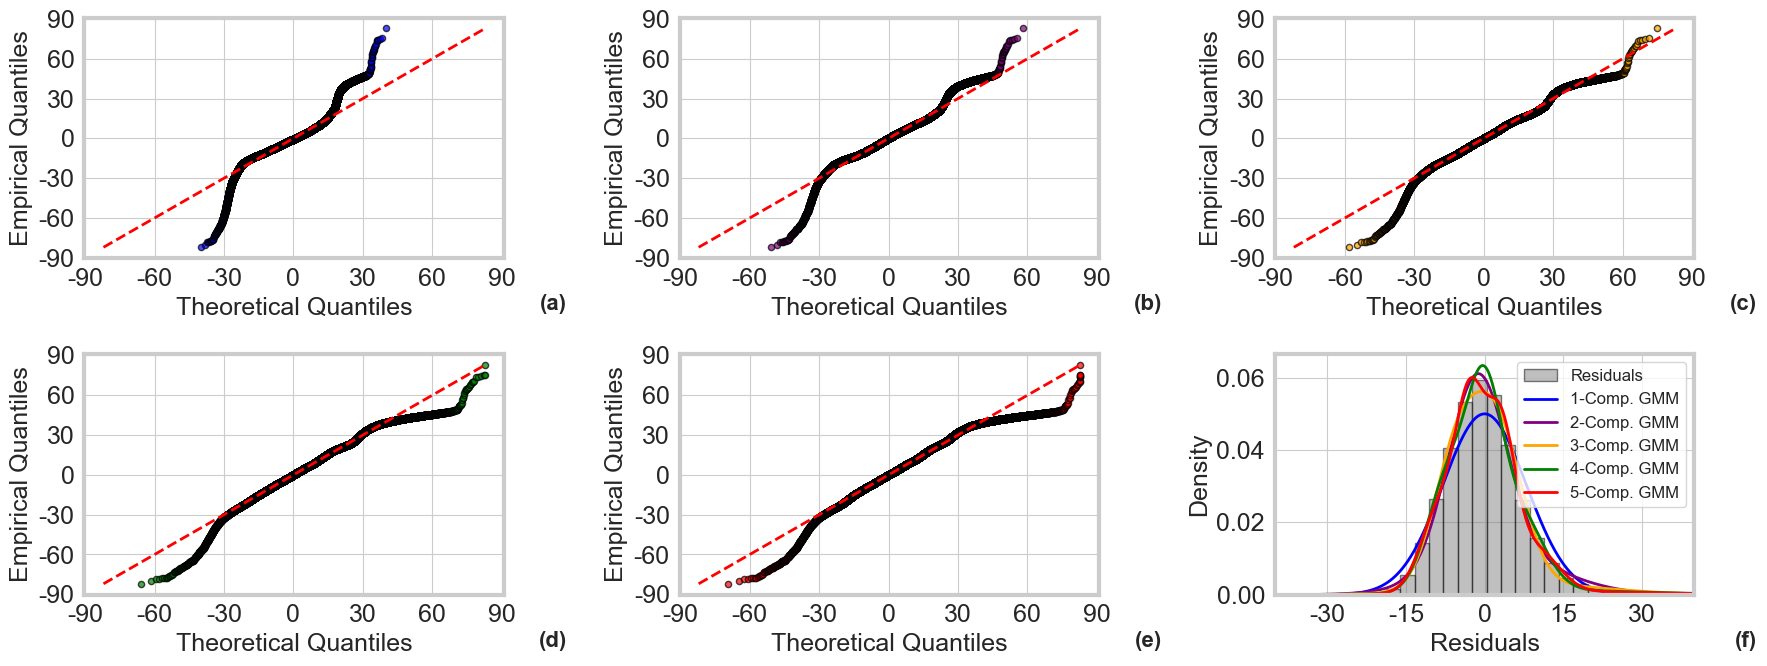

In [29]:
#  Re-fit GMM models for 1 to 5 components and store them in a list
gmm_models = []
for k in range(1, 6):
    gmm_k = GaussianMixture(n_components=k, random_state=42).fit(residuals_array)
    gmm_models.append(gmm_k)

# Prepare sorted residuals and the corresponding probability positions
sorted_residuals = np.sort(residuals)
n = len(sorted_residuals)
probs = (np.arange(1, n + 1) - 0.5) / n  # Probability positions for quantiles

#  Create a 2x3 grid for Q–Q plots and the combined histogram 
fig, axes = plt.subplots(2, 3, figsize=(18, 7))
axes = axes.flatten()
subplot_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
gmm_colors = ['blue', 'purple', 'orange', 'green', 'red']

#  Plot Q–Q plots for each of the 5 GMM models 
for i, gmm_model in enumerate(gmm_models):
    ax = axes[i]
    
    # Generate a dense grid to compute the GMM CDF
    x_grid = np.linspace(residuals.min(), residuals.max(), 200000)
    cdf_grid = gmm_cdf(x_grid, gmm_model)
    
    # Remove duplicate CDF values for reliable interpolation
    unique_cdf, unique_idx = np.unique(cdf_grid, return_index=True)
    unique_x = x_grid[unique_idx]
    # Create an interpolation function (PPF) from CDF to quantiles
    ppf_func = interp1d(unique_cdf, unique_x, bounds_error=False, fill_value=(x_grid[0], x_grid[-1]))
    theoretical_quantiles = ppf_func(probs)
    
    # Scatter the theoretical versus empirical quantiles
    ax.scatter(theoretical_quantiles, sorted_residuals, color=gmm_colors[i], alpha=0.7, edgecolors='k', s=20)
    # Plot a 45° reference line
    min_val = min(theoretical_quantiles.min(), sorted_residuals.min())
    max_val = max(theoretical_quantiles.max(), sorted_residuals.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    
    ax.set_xlabel('Theoretical Quantiles', fontsize=18)
    ax.set_ylabel('Empirical Quantiles', fontsize=18)
    #ax.set_title(f'GMM with {i+1} Component(s)', fontsize=20)
    ax.text(1.15, -0.15, subplot_labels[i], transform=ax.transAxes, ha='right', va='top', fontweight='bold', fontsize=16)
    ax.grid(True)

#  Plot the 6th subplot: Histogram of residuals with overlaid GMM densities 
ax6 = axes[5]
ax6.hist(residuals, bins=60, density=True, alpha=0.5, color='grey', edgecolor='black', label='Residuals')
x_vals = np.linspace(residuals.min(), residuals.max(), 1000)
for i, gmm_model in enumerate(gmm_models):
    # Compute the density for the current GMM (exponentiate the log probabilities)
    density = np.exp(gmm_model.score_samples(x_vals.reshape(-1, 1)))
    ax6.plot(x_vals, density, color=gmm_colors[i], linewidth=2, label=f'{i+1}-Comp. GMM')
    
ax6.set_xlabel('Residuals', fontsize=18)
ax6.set_ylabel('Density', fontsize=18)
ax6.legend(fontsize=12)
ax6.set_xlim(-40, 40)
ax6.grid(True)
ax6.text(1.15, -0.15, subplot_labels[5], transform=ax6.transAxes, ha='right', va='top', fontweight='bold', fontsize=16)

# Set tick intervals and font sizes
for i, ax in enumerate(axes):
    if i < 5:  # Subplots (a) to (e)
        ax.xaxis.set_major_locator(MultipleLocator(30))
        ax.yaxis.set_major_locator(MultipleLocator(30))
    elif i == 5:  # Subplot (f)
        ax.xaxis.set_major_locator(MultipleLocator(15))
    
    # Set tick font size
    ax.tick_params(axis='both', which='major', labelsize=18)
    
    # Set border width
    for spine in ax.spines.values():
        spine.set_linewidth(3)
        
plt.tight_layout()
#plt.savefig('Plots+Results/gmm_qq_residual_plots.png', dpi=1000)
plt.show()

In [30]:
#  Print Distribution Parameters Including Best GMM 

def print_group(title, params):
    bold_title = f"\033[1m{title}\033[0m"
    print(bold_title)
    for name, val in params:
        print(f"{name}: {val:.4f}")
    print("-" * 50)

# Normal Distribution
print_group("Normal Distribution", [("Mean (μ)", loc_norm), ("Std (σ)", scale_norm)])

# Skew-Normal Distribution
print_group("Skew-Normal Distribution", [("Shape", shape_sn), ("Location", loc_sn), ("Scale", scale_sn)])

# Gaussian Mixture Model (Using Best GMM from Diagnostics)
bold_title = f"\033[1m Gaussian Mixture Model (Best GMM) \033[0m"
print(bold_title)
for i in range(best_gmm.n_components):
    print(f"Component {i+1}:")
    print(f"  Weight (π): {best_gmm.weights_[i]:.4f}")
    if best_gmm.covariances_.ndim == 3:
        std = np.sqrt(best_gmm.covariances_[i][0][0])
    else:
        std = np.sqrt(best_gmm.covariances_[i])
    mean = best_gmm.means_[i][0]
    print(f"  Mean (μ):   {mean:.4f}")
    print(f"  Std (σ):    {std:.4f}")
print("-" * 50)

# Cauchy Distribution
print_group("Cauchy Distribution", [("Location", cauchy_params[0]), ("Scale", cauchy_params[1])])

# t-Distribution
print_group("t-Distribution", [("Degrees of Freedom (df)", df_t), ("Location", loc_t), ("Scale", scale_t)])

Normal Distribution
Mean (μ): 0.0000
Std (σ): 7.9807
--------------------------------------------------
Skew-Normal Distribution
Shape: 1.9049
Location: -7.6883
Scale: 11.0815
--------------------------------------------------
 Gaussian Mixture Model (Best GMM) 
Component 1:
  Weight (π): 0.4320
  Mean (μ):   -0.1102
  Std (σ):    3.4042
Component 2:
  Weight (π): 0.2956
  Mean (μ):   -7.1087
  Std (σ):    3.9328
Component 3:
  Weight (π): 0.0554
  Mean (μ):   11.5194
  Std (σ):    17.5386
Component 4:
  Weight (π): 0.2170
  Mean (μ):   6.9629
  Std (σ):    4.4287
--------------------------------------------------
Cauchy Distribution
Location: -0.7022
Scale: 4.1555
--------------------------------------------------
t-Distribution
Degrees of Freedom (df): 4.7743
Location: -0.5184
Scale: 6.0169
--------------------------------------------------


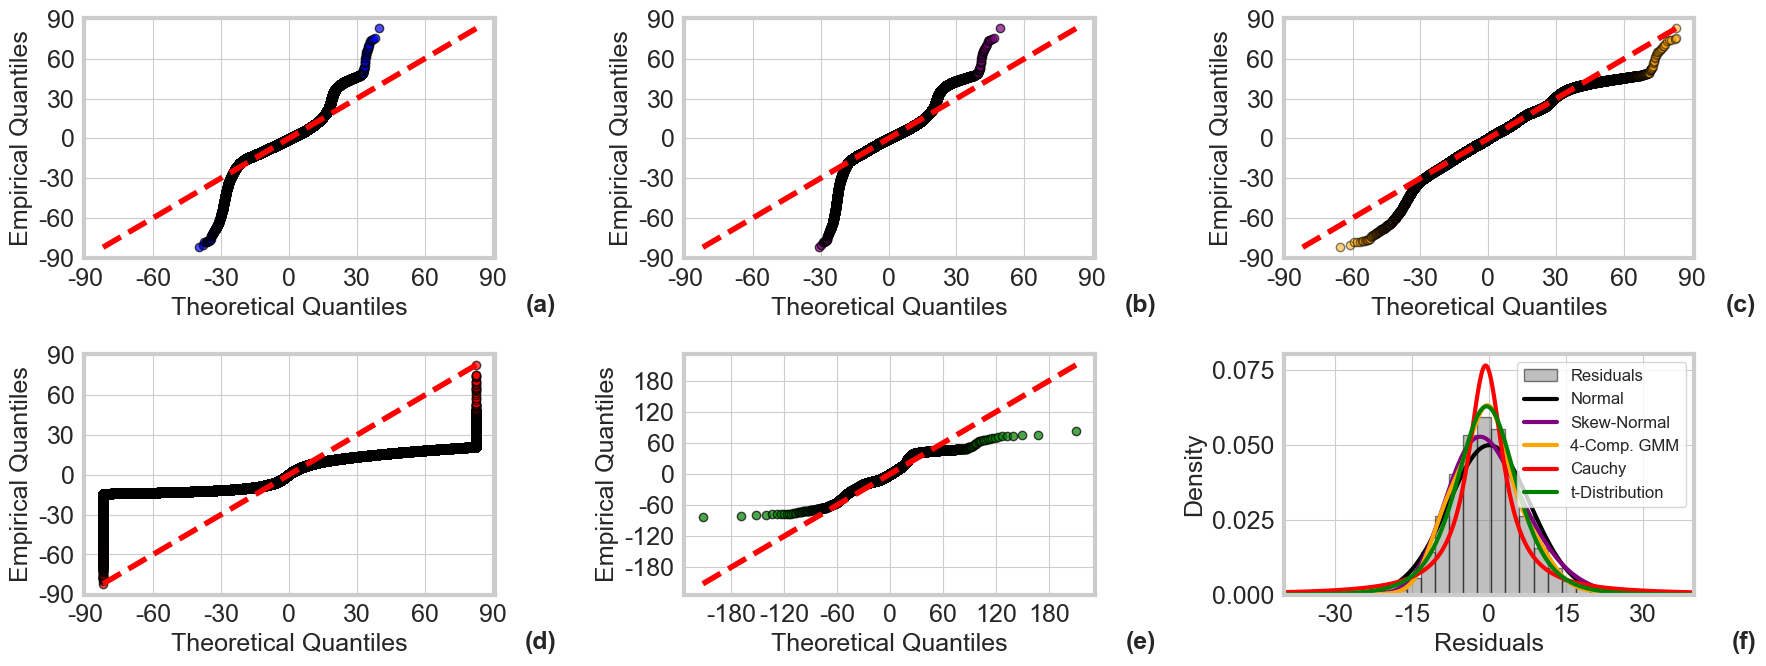

In [31]:
#  Plot Diagnostic Subplots in a 2x3 Grid 
plt.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 20,
    'axes.labelsize': 18,
    'legend.fontsize': 15
})

fig, axes = plt.subplots(2, 3, figsize=(18, 7))  # 2 rows, 3 columns
axes = axes.flatten()  # Flatten to 1D array for easy indexing

# Define subplot labels for the six subplots
subplot_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

# Function to create manual Q-Q plots
def manual_qq_plot(distribution, dist_name, sorted_residuals, probabilities, ax, color='blue'):
    """
    Create a manual Q-Q plot.
    """
    theoretical_quantiles = distribution.ppf(probabilities)
    ax.scatter(theoretical_quantiles, sorted_residuals, edgecolors='k', facecolor=color, alpha=0.7)
    min_val = min(theoretical_quantiles.min(), sorted_residuals.min())
    max_val = max(theoretical_quantiles.max(), sorted_residuals.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=4)
    #ax.set_title(f'{dist_name} Distribution')
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Empirical Quantiles')
    ax.grid(True)

# 1. Q-Q Plot (Normal Distribution)
manual_qq_plot(normal_dist, 'Normal', sorted_residuals, probabilities, axes[0], color='blue')
axes[0].text(1.15, -0.15, subplot_labels[0], transform=axes[0].transAxes,
             ha='right', va='top', fontweight='bold', fontsize=18)

# 2. Q-Q Plot (Skew-Normal Distribution)
manual_qq_plot(skew_dist, 'Skew-Normal', sorted_residuals, probabilities, axes[1], color='purple')
axes[1].text(1.15, -0.15, subplot_labels[1], transform=axes[1].transAxes,
             ha='right', va='top', fontweight='bold', fontsize=18)

# 3. Q-Q Plot (Gaussian Mixture Model)
x_grid = np.linspace(residuals.min(), residuals.max(), 200000)
cdf_grid = gmm_cdf(x_grid, best_gmm)  # Using best_gmm here
unique_cdf, unique_indices = np.unique(cdf_grid, return_index=True)
unique_x = x_grid[unique_indices]
ppf_func = interp1d(unique_cdf, unique_x, bounds_error=False, fill_value=(x_grid[0], x_grid[-1]))
theoretical_gmm_quantiles = ppf_func(probabilities)

axes[2].scatter(theoretical_gmm_quantiles, sorted_residuals, edgecolors='k', facecolor='orange', alpha=0.5)
min_val = min(theoretical_gmm_quantiles.min(), sorted_residuals.min())
max_val = max(theoretical_gmm_quantiles.max(), sorted_residuals.max())
axes[2].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=4)
#axes[2].set_title('GMM Distribution')
axes[2].set_xlabel('Theoretical Quantiles')
axes[2].set_ylabel('Empirical Quantiles')
axes[2].grid(True)
axes[2].text(1.15, -0.15, subplot_labels[2], transform=axes[2].transAxes,
             ha='right', va='top', fontweight='bold', fontsize=18)

# 4. Q-Q Plot (Cauchy Distribution)
lower_bound = residuals.min()
upper_bound = residuals.max()
theoretical_quantiles = cauchy_dist.ppf(probabilities)
theoretical_quantiles_clipped = np.clip(theoretical_quantiles, lower_bound, upper_bound)

axes[3].scatter(theoretical_quantiles_clipped, sorted_residuals, edgecolors='k', facecolor='red', alpha=0.7)
axes[3].plot([lower_bound, upper_bound], [lower_bound, upper_bound], 'r--', linewidth=4)
#axes[3].set_title('Cauchy Distribution')
axes[3].set_xlabel('Theoretical Quantiles')
axes[3].set_ylabel('Empirical Quantiles')
axes[3].grid(True)
axes[3].text(1.15, -0.15, subplot_labels[3], transform=axes[3].transAxes,
             ha='right', va='top', fontweight='bold', fontsize=18)

# 5. Q-Q Plot (t-Distribution)
manual_qq_plot(t_dist, 't-', sorted_residuals, probabilities, axes[4], color='green')
axes[4].text(1.15, -0.15, subplot_labels[4], transform=axes[4].transAxes,
             ha='right', va='top', fontweight='bold', fontsize=18)

# 6. Residuals Histogram with Fitted Densities
axes[5].hist(residuals, bins=60, density=True, alpha=0.5, color='grey', edgecolor='black', label='Residuals')
x_vals = np.linspace(residuals.min(), residuals.max(), 1000)
axes[5].plot(x_vals, normal_dist.pdf(x_vals), label='Normal', color='black', linewidth=3)
axes[5].plot(x_vals, skew_dist.pdf(x_vals), label='Skew-Normal', color='purple', linewidth=3)
# Using best_gmm to compute density
gmm_density = np.exp(best_gmm.score_samples(x_vals.reshape(-1, 1)))
axes[5].plot(x_vals, gmm_density, label='4-Comp. GMM', color='orange', linewidth=3)
axes[5].plot(x_vals, cauchy_dist.pdf(x_vals), label='Cauchy', color='red', linewidth=3)
axes[5].plot(x_vals, t_dist.pdf(x_vals), label='t-Distribution', color='green', linewidth=3)
#axes[5].set_title('Residuals Distributions')
axes[5].set_xlabel('Residuals')
axes[5].set_ylabel('Density')
axes[5].legend(fontsize=12)
axes[5].grid(True)
axes[5].set_xlim(-40, 40)
axes[5].text(1.15, -0.15, subplot_labels[5], transform=axes[5].transAxes,
             ha='right', va='top', fontweight='bold', fontsize=18)

#  Tick Interval Adjustments 
# For subplots a-d (axes[0] to axes[3]), 30
for i in range(0, 4):
    axes[i].xaxis.set_major_locator(MultipleLocator(30))
    axes[i].yaxis.set_major_locator(MultipleLocator(30))

# For subplot e (axes[4]), 60
axes[4].xaxis.set_major_locator(MultipleLocator(60))
axes[4].yaxis.set_major_locator(MultipleLocator(60))

# For histogram subplot f (axes[5]), 15
axes[5].xaxis.set_major_locator(MultipleLocator(15))
#  End of Tick Interval Adjustments 

# Adjust tick font size for all subplots
for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=18)

# Set all subplot border widths (spines) to 3 
for ax in axes:
    for spine in ax.spines.values():
        spine.set_linewidth(3)

# Adjust layout, save figure, and display
plt.tight_layout()
#plt.savefig('Plots+Results/qq_residual_plots.png', dpi=1000)
plt.show()

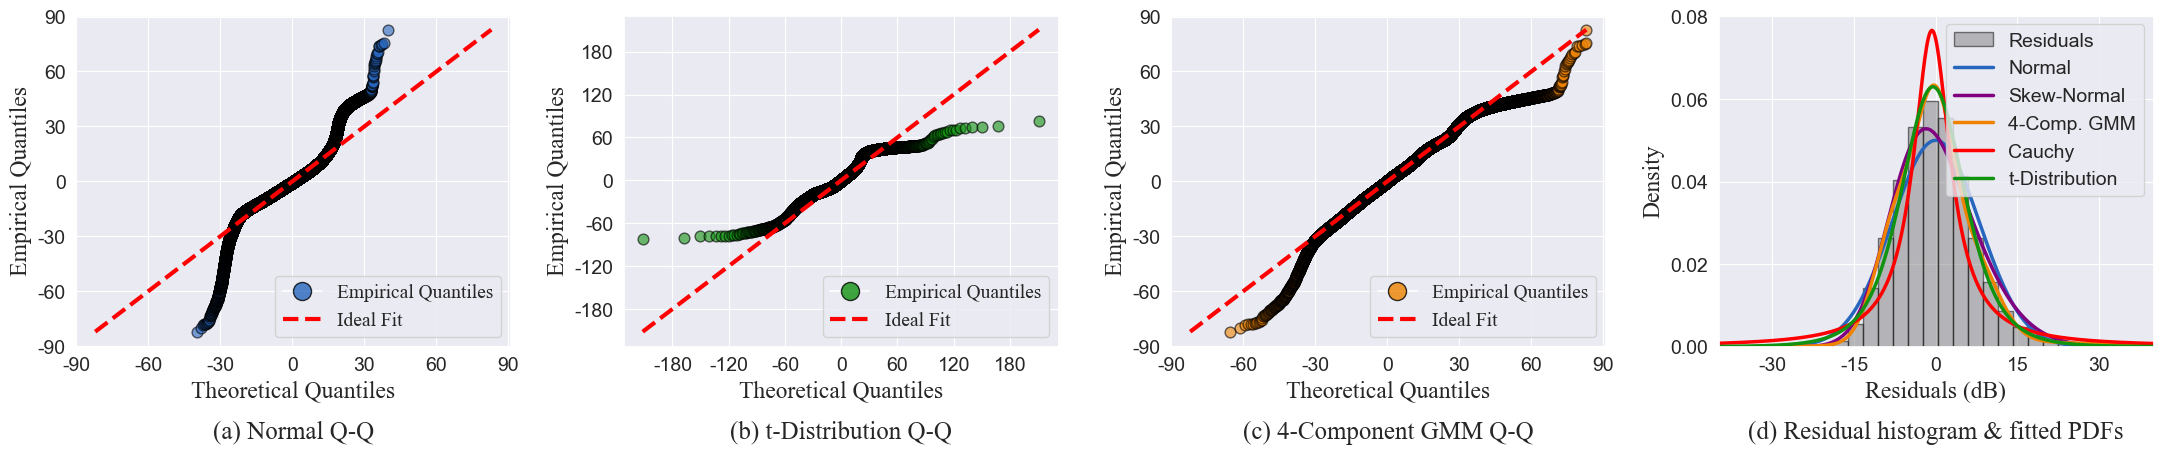

In [32]:
#  FONT SIZE METRICS 
tick_fontsize   = 14
axis_labelsize  = 17
legend_fontsize = 14
ab_fontsize     = 18
label_ypos      = -0.22   # position for (a)-(d) label

sns.set_style("darkgrid")
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
qq_colors = ['#2766bd', '#119211', '#ef8301']  # blue, green, orange

#  (a) Normal Q-Q 
theoretical_norm = normal_dist.ppf(probabilities)
axes[0].scatter(theoretical_norm, sorted_residuals,
                edgecolor='k', facecolor=qq_colors[0], alpha=0.6, s=60)
min_val = min(theoretical_norm.min(), sorted_residuals.min())
max_val = max(theoretical_norm.max(), sorted_residuals.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=3)
axes[0].set_xlabel('Theoretical Quantiles', fontsize=axis_labelsize, fontname='Times New Roman')
axes[0].set_ylabel('Empirical Quantiles', fontsize=axis_labelsize, fontname='Times New Roman')
axes[0].tick_params(axis='both', which='major', labelsize=tick_fontsize)
axes[0].xaxis.set_major_locator(MultipleLocator(30))
axes[0].yaxis.set_major_locator(MultipleLocator(30))
axes[0].text(0.5, label_ypos, '(a) Normal Q-Q', transform=axes[0].transAxes,
             fontsize=ab_fontsize, va='top', ha='center', fontname='Times New Roman')
for spine in axes[0].spines.values():
    spine.set_linewidth(2.0)
legend_a = [
    Line2D([0], [0], marker='o', color='w', label='Empirical Quantiles',
           markerfacecolor=qq_colors[0], markeredgecolor='k', markersize=10, alpha=0.8),
    Line2D([0], [0], color='r', lw=3, linestyle='--', label='Ideal Fit'),
]
leg1 = axes[0].legend(handles=legend_a, fontsize=legend_fontsize, loc='lower right',
                      handlelength=2, markerscale=1.3, frameon=True)
for t in leg1.get_texts():
    t.set_fontname('Times New Roman')

#  (b) t-Distribution Q-Q 
theoretical_t = t_dist.ppf(probabilities)
axes[1].scatter(theoretical_t, sorted_residuals,
                edgecolor='k', facecolor=qq_colors[1], alpha=0.6, s=60)
min_val = min(theoretical_t.min(), sorted_residuals.min())
max_val = max(theoretical_t.max(), sorted_residuals.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=3)
axes[1].set_xlabel('Theoretical Quantiles', fontsize=axis_labelsize, fontname='Times New Roman')
axes[1].set_ylabel('Empirical Quantiles', fontsize=axis_labelsize, fontname='Times New Roman')
axes[1].tick_params(axis='both', which='major', labelsize=tick_fontsize)
axes[1].xaxis.set_major_locator(MultipleLocator(60))
axes[1].yaxis.set_major_locator(MultipleLocator(60))
axes[1].text(0.5, label_ypos, '(b) t-Distribution Q-Q', transform=axes[1].transAxes,
             fontsize=ab_fontsize, va='top', ha='center', fontname='Times New Roman')
for spine in axes[1].spines.values():
    spine.set_linewidth(2.0)
legend_b = [
    Line2D([0], [0], marker='o', color='w', label='Empirical Quantiles',
           markerfacecolor=qq_colors[1], markeredgecolor='k', markersize=10, alpha=0.8),
    Line2D([0], [0], color='r', lw=3, linestyle='--', label='Ideal Fit'),
]
leg2 = axes[1].legend(handles=legend_b, fontsize=legend_fontsize, loc='lower right',
                      handlelength=2, markerscale=1.3, frameon=True)
for t in leg2.get_texts():
    t.set_fontname('Times New Roman')

#  (c) 4-comp GMM Q-Q 
x_grid = np.linspace(residuals.min(), residuals.max(), 200000)
cdf_grid = gmm_cdf(x_grid, best_gmm)
unique_cdf, unique_indices = np.unique(cdf_grid, return_index=True)
unique_x = x_grid[unique_indices]
from scipy.interpolate import interp1d
ppf_func = interp1d(unique_cdf, unique_x, bounds_error=False, fill_value=(x_grid[0], x_grid[-1]))
theoretical_gmm_quantiles = ppf_func(probabilities)
axes[2].scatter(theoretical_gmm_quantiles, sorted_residuals,
                edgecolor='k', facecolor=qq_colors[2], alpha=0.6, s=60)
min_val = min(theoretical_gmm_quantiles.min(), sorted_residuals.min())
max_val = max(theoretical_gmm_quantiles.max(), sorted_residuals.max())
axes[2].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=3)
axes[2].set_xlabel('Theoretical Quantiles', fontsize=axis_labelsize, fontname='Times New Roman')
axes[2].set_ylabel('Empirical Quantiles', fontsize=axis_labelsize, fontname='Times New Roman')
axes[2].tick_params(axis='both', which='major', labelsize=tick_fontsize)
axes[2].xaxis.set_major_locator(MultipleLocator(30))
axes[2].yaxis.set_major_locator(MultipleLocator(30))
axes[2].text(0.5, label_ypos, '(c) 4-Component GMM Q-Q', transform=axes[2].transAxes,
             fontsize=ab_fontsize, va='top', ha='center', fontname='Times New Roman')
for spine in axes[2].spines.values():
    spine.set_linewidth(2.0)
legend_c = [
    Line2D([0], [0], marker='o', color='w', label='Empirical Quantiles',
           markerfacecolor=qq_colors[2], markeredgecolor='k', markersize=10, alpha=0.8),
    Line2D([0], [0], color='r', lw=3, linestyle='--', label='Ideal Fit'),
]
leg3 = axes[2].legend(handles=legend_c, fontsize=legend_fontsize, loc='lower right',
                      handlelength=2, markerscale=1.3, frameon=True)
for t in leg3.get_texts():
    t.set_fontname('Times New Roman')

#  (d) Residuals Histogram with All Fitted PDFs 
x_vals = np.linspace(residuals.min(), residuals.max(), 1000)
axes[3].hist(residuals, bins=60, density=True, alpha=0.5, color='grey', edgecolor='black', label='Residuals')
axes[3].plot(x_vals, normal_dist.pdf(x_vals), label='Normal', color='#2766bd', linewidth=2.5)
axes[3].plot(x_vals, skew_dist.pdf(x_vals), label='Skew-Normal', color='purple', linewidth=2.5)
gmm_density = np.exp(best_gmm.score_samples(x_vals.reshape(-1, 1)))
axes[3].plot(x_vals, gmm_density, label='4-Comp. GMM', color='#ef8301', linewidth=2.5)
axes[3].plot(x_vals, cauchy_dist.pdf(x_vals), label='Cauchy', color='red', linewidth=2.5)
axes[3].plot(x_vals, t_dist.pdf(x_vals), label='t-Distribution', color='#119211', linewidth=2.5)
axes[3].set_xlabel('Residuals (dB)', fontsize=axis_labelsize, fontname='Times New Roman')
axes[3].set_ylabel('Density', fontsize=axis_labelsize, fontname='Times New Roman')
axes[3].tick_params(axis='both', which='major', labelsize=tick_fontsize)
axes[3].set_xlim(-40, 40)
axes[3].legend(fontsize=legend_fontsize, loc='upper right')
axes[3].text(0.5, label_ypos, '(d) Residual histogram & fitted PDFs', transform=axes[3].transAxes,
             fontsize=ab_fontsize, va='top', ha='center', fontname='Times New Roman')
axes[3].xaxis.set_major_locator(MultipleLocator(15))
axes[3].yaxis.set_major_locator(MultipleLocator(0.02))
for spine in axes[3].spines.values():
    spine.set_linewidth(2.0)

plt.tight_layout()
#plt.savefig('Plots+Results/residualdistributionanalysis.png', dpi=1200, bbox_inches='tight')
plt.show()

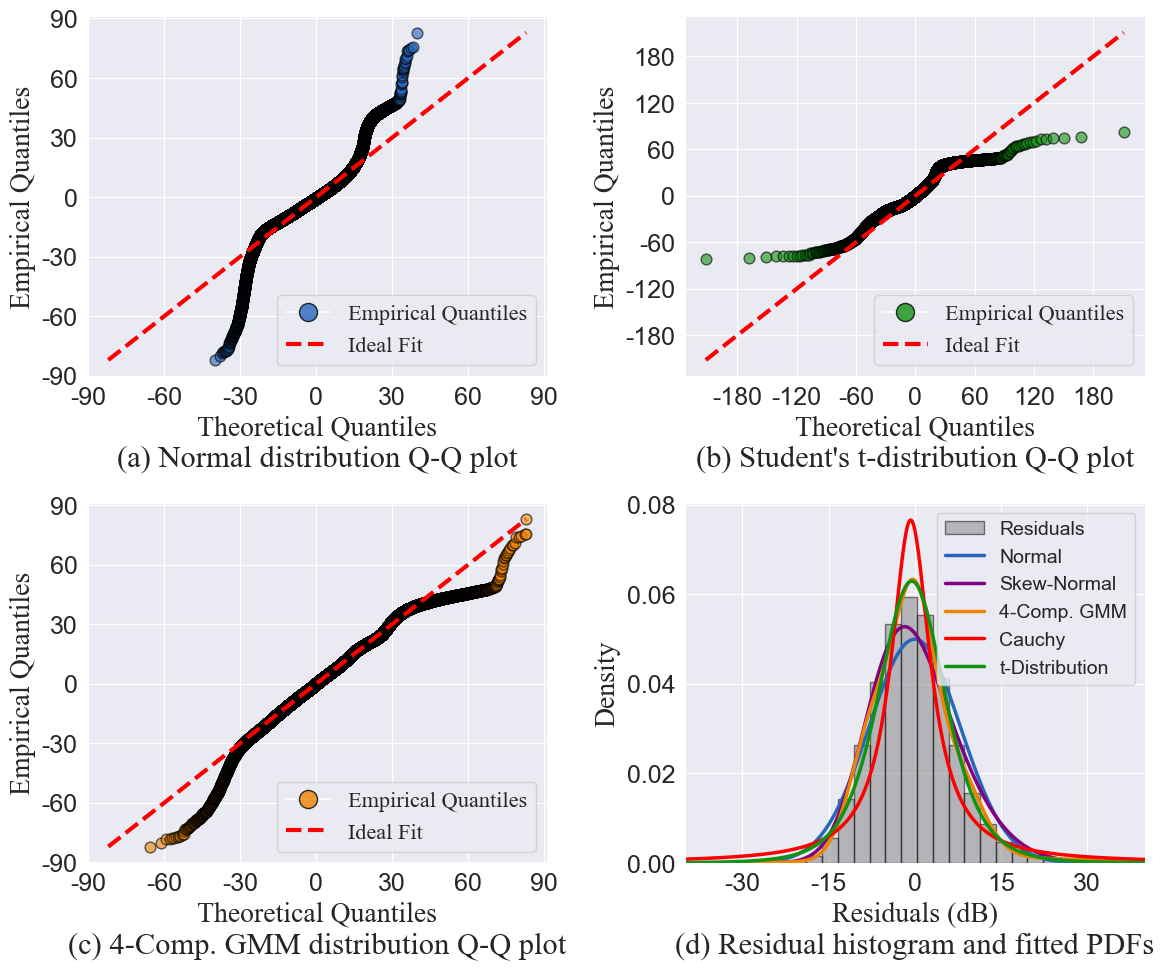

In [33]:
#  FONT SIZE METRICS 
tick_fontsize   = 18
axis_labelsize  = 20
legend_fontsize = 16
ab_fontsize     = 22
label_ypos      = -0.19   # vertical position for (a)-(d) labels

sns.set_style("darkgrid")
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
qq_colors = ['#2766bd', '#119211', '#ef8301']  # blue, green, orange

# (a) Normal Q-Q (axes[0,0])
theoretical_norm = normal_dist.ppf(probabilities)
axes[0, 0].scatter(theoretical_norm, sorted_residuals,
                   edgecolor='k', facecolor=qq_colors[0], alpha=0.6, s=60)
min_val = min(theoretical_norm.min(), sorted_residuals.min())
max_val = max(theoretical_norm.max(), sorted_residuals.max())
axes[0, 0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=3)
axes[0, 0].set_xlabel('Theoretical Quantiles', fontsize=axis_labelsize, fontname='Times New Roman')
axes[0, 0].set_ylabel('Empirical Quantiles', fontsize=axis_labelsize, fontname='Times New Roman')
axes[0, 0].tick_params(axis='both', which='major', labelsize=tick_fontsize)
axes[0, 0].xaxis.set_major_locator(MultipleLocator(30))
axes[0, 0].yaxis.set_major_locator(MultipleLocator(30))
axes[0, 0].text(0.5, label_ypos, '(a) Normal distribution Q-Q plot', transform=axes[0, 0].transAxes,
                fontsize=ab_fontsize, va='top', ha='center', fontname='Times New Roman')
legend_a = [
    Line2D([0], [0], marker='o', color='w', label='Empirical Quantiles',
           markerfacecolor=qq_colors[0], markeredgecolor='k', markersize=10, alpha=0.8),
    Line2D([0], [0], color='r', lw=3, linestyle='--', label='Ideal Fit'),
]
leg1 = axes[0, 0].legend(handles=legend_a, fontsize=legend_fontsize, loc='lower right',
                         handlelength=2, markerscale=1.3, frameon=True)
for t in leg1.get_texts():
    t.set_fontname('Times New Roman')

# (b) t-Distribution Q-Q (axes[0,1])
theoretical_t = t_dist.ppf(probabilities)
axes[0, 1].scatter(theoretical_t, sorted_residuals,
                   edgecolor='k', facecolor=qq_colors[1], alpha=0.6, s=60)
min_val = min(theoretical_t.min(), sorted_residuals.min())
max_val = max(theoretical_t.max(), sorted_residuals.max())
axes[0, 1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=3)
axes[0, 1].set_xlabel('Theoretical Quantiles', fontsize=axis_labelsize, fontname='Times New Roman')
axes[0, 1].set_ylabel('Empirical Quantiles', fontsize=axis_labelsize, fontname='Times New Roman')
axes[0, 1].tick_params(axis='both', which='major', labelsize=tick_fontsize)
axes[0, 1].xaxis.set_major_locator(MultipleLocator(60))
axes[0, 1].yaxis.set_major_locator(MultipleLocator(60))
axes[0, 1].text(0.5, label_ypos, '(b) Student\'s t-distribution Q-Q plot', transform=axes[0, 1].transAxes,
                fontsize=ab_fontsize, va='top', ha='center', fontname='Times New Roman')
legend_b = [
    Line2D([0], [0], marker='o', color='w', label='Empirical Quantiles',
           markerfacecolor=qq_colors[1], markeredgecolor='k', markersize=10, alpha=0.8),
    Line2D([0], [0], color='r', lw=3, linestyle='--', label='Ideal Fit'),
]
leg2 = axes[0, 1].legend(handles=legend_b, fontsize=legend_fontsize, loc='lower right',
                         handlelength=2, markerscale=1.3, frameon=True)
for t in leg2.get_texts():
    t.set_fontname('Times New Roman')

# (c) 4-comp GMM Q-Q (axes[1,0])
x_grid = np.linspace(residuals.min(), residuals.max(), 200000)
cdf_grid = gmm_cdf(x_grid, best_gmm)
unique_cdf, unique_indices = np.unique(cdf_grid, return_index=True)
unique_x = x_grid[unique_indices]

ppf_func = interp1d(unique_cdf, unique_x, bounds_error=False, fill_value=(x_grid[0], x_grid[-1]))
theoretical_gmm_quantiles = ppf_func(probabilities)
axes[1, 0].scatter(theoretical_gmm_quantiles, sorted_residuals,
                   edgecolor='k', facecolor=qq_colors[2], alpha=0.6, s=60)
min_val = min(theoretical_gmm_quantiles.min(), sorted_residuals.min())
max_val = max(theoretical_gmm_quantiles.max(), sorted_residuals.max())
axes[1, 0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=3)
axes[1, 0].set_xlabel('Theoretical Quantiles', fontsize=axis_labelsize, fontname='Times New Roman')
axes[1, 0].set_ylabel('Empirical Quantiles', fontsize=axis_labelsize, fontname='Times New Roman')
axes[1, 0].tick_params(axis='both', which='major', labelsize=tick_fontsize)
axes[1, 0].xaxis.set_major_locator(MultipleLocator(30))
axes[1, 0].yaxis.set_major_locator(MultipleLocator(30))
axes[1, 0].text(0.5, label_ypos, '(c) 4-Comp. GMM distribution Q-Q plot', transform=axes[1, 0].transAxes,
                fontsize=ab_fontsize, va='top', ha='center', fontname='Times New Roman')
legend_c = [
    Line2D([0], [0], marker='o', color='w', label='Empirical Quantiles',
           markerfacecolor=qq_colors[2], markeredgecolor='k', markersize=10, alpha=0.8),
    Line2D([0], [0], color='r', lw=3, linestyle='--', label='Ideal Fit'),
]
leg3 = axes[1, 0].legend(handles=legend_c, fontsize=legend_fontsize, loc='lower right',
                         handlelength=2, markerscale=1.3, frameon=True)
for t in leg3.get_texts():
    t.set_fontname('Times New Roman')

# (d) Residuals Histogram with Fitted PDFs (axes[1,1])
x_vals = np.linspace(residuals.min(), residuals.max(), 1000)
axes[1, 1].hist(residuals, bins=60, density=True, alpha=0.5, color='grey', edgecolor='black', label='Residuals')
axes[1, 1].plot(x_vals, normal_dist.pdf(x_vals), label='Normal', color='#2766bd', linewidth=2.5)
axes[1, 1].plot(x_vals, skew_dist.pdf(x_vals), label='Skew-Normal', color='purple', linewidth=2.5)
gmm_density = np.exp(best_gmm.score_samples(x_vals.reshape(-1, 1)))
axes[1, 1].plot(x_vals, gmm_density, label='4-Comp. GMM', color='#ef8301', linewidth=2.5)
axes[1, 1].plot(x_vals, cauchy_dist.pdf(x_vals), label='Cauchy', color='red', linewidth=2.5)
axes[1, 1].plot(x_vals, t_dist.pdf(x_vals), label='t-Distribution', color='#119211', linewidth=2.5)
axes[1, 1].set_xlabel('Residuals (dB)', fontsize=axis_labelsize, fontname='Times New Roman')
axes[1, 1].set_ylabel('Density', fontsize=axis_labelsize, fontname='Times New Roman')
axes[1, 1].tick_params(axis='both', which='major', labelsize=tick_fontsize)
axes[1, 1].set_xlim(-40, 40)
axes[1, 1].legend(fontsize=14, loc='upper right')
axes[1, 1].text(0.5, label_ypos, '(d) Residual histogram and fitted PDFs', transform=axes[1, 1].transAxes,
                fontsize=ab_fontsize, va='top', ha='center', fontname='Times New Roman')
axes[1, 1].xaxis.set_major_locator(MultipleLocator(15))
axes[1, 1].yaxis.set_major_locator(MultipleLocator(0.02))

plt.tight_layout(w_pad=0.0, h_pad=2.5)

plt.tight_layout()
#plt.savefig('Plots+Results/residualdistributionanalysis.png', dpi=1200, bbox_inches='tight')
plt.show()

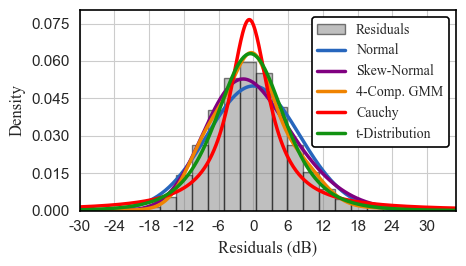

In [34]:
#  FONT SIZE METRICS 
axis_labelsize  = 12
tick_fontsize   = 11
legend_fontsize = 10

sns.set_style("whitegrid")

#  Single histogram figure 
fig, ax = plt.subplots(figsize=(5, 3))

x_vals = np.linspace(residuals.min(), residuals.max(), 1000)

# Histogram of residuals
ax.hist(
    residuals,
    bins=60,
    density=True,
    alpha=0.5,
    color='grey',
    edgecolor='black',
    label='Residuals'
)

# Fitted PDFs
ax.plot(x_vals, normal_dist.pdf(x_vals),          label='Normal',         color='#2766bd', linewidth=2.5)
ax.plot(x_vals, skew_dist.pdf(x_vals),            label='Skew-Normal',    color='purple',  linewidth=2.5)

gmm_density = np.exp(best_gmm.score_samples(x_vals.reshape(-1, 1)))
ax.plot(x_vals, gmm_density,                      label='4-Comp. GMM',    color='#ef8301', linewidth=2.5)

ax.plot(x_vals, cauchy_dist.pdf(x_vals),          label='Cauchy',         color='red',     linewidth=2.5)
ax.plot(x_vals, t_dist.pdf(x_vals),               label='t-Distribution', color='#119211', linewidth=2.5)

# Axes formatting
ax.set_xlabel('Residuals (dB)', fontsize=axis_labelsize, fontname='Times New Roman')
ax.set_ylabel('Density',        fontsize=axis_labelsize, fontname='Times New Roman')
ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
ax.set_xlim(-30, 35)
ax.xaxis.set_major_locator(MultipleLocator(6))
ax.yaxis.set_major_locator(MultipleLocator(0.015))

# axes spines
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('black')
    spine.set_linewidth(1.2)

# Legend 
leg = ax.legend(fontsize=legend_fontsize, loc='upper right')
for t in leg.get_texts():
    t.set_fontname('Times New Roman')

leg.get_frame().set_edgecolor('black')
leg.get_frame().set_linewidth(1.2)
leg.get_frame().set_facecolor('white')
leg.get_frame().set_alpha(1.0)

plt.tight_layout()
plt.savefig('Plots+Results/residual_hist.png', dpi=2000, bbox_inches='tight')
plt.show()